Using Colab cache for faster access to the 'dermnet' dataset.
DermNet dataset downloaded to: /kaggle/input/dermnet
Using Colab cache for faster access to the 'skin-cancer-mnist-ham10000' dataset.
HAM10000 dataset downloaded to: /kaggle/input/skin-cancer-mnist-ham10000
Total images found: 15557
Number of classes: 23
Classes: ['Acne and Rosacea Photos', 'Actinic Keratosis Basal Cell Carcinoma and other Malignant Lesions', 'Atopic Dermatitis Photos', 'Bullous Disease Photos', 'Cellulitis Impetigo and other Bacterial Infections', 'Eczema Photos', 'Exanthems and Drug Eruptions', 'Hair Loss Photos Alopecia and other Hair Diseases', 'Herpes HPV and other STDs Photos', 'Light Diseases and Disorders of Pigmentation', 'Lupus and other Connective Tissue diseases', 'Melanoma Skin Cancer Nevi and Moles', 'Nail Fungus and other Nail Disease', 'Poison Ivy Photos and other Contact Dermatitis', 'Psoriasis pictures Lichen Planus and related diseases', 'Scabies Lyme Disease and other Infestations and Bit

/tmp/ipython-input-4114877579.py:177: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  base = MobileNetV2(


Model: "mobilenetv2_derm"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ image (InputLayer)              │ (None, 256, 256, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ augment (Sequential)            │ (None, 256, 256, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lambda_3 (Lambda)               │ (None, 256, 256, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 8, 8, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_3      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 384)            │       491,904 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 384)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pred (Dense)                    │ (None, 23)             │         8,855 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,758,743 (10.52 MB)

 Trainable params: 500,759 (1.91 MB)

 Non-trainable params: 2,257,984 (8.61 MB)

Epoch 1/20
352/352 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.1364 - loss: 3.1106 - top2: 0.2180 - top3: 0.2735
Epoch 1: val_accuracy improved from -inf to 0.22329, saving model to best_skin_mnv2.keras
352/352 ━━━━━━━━━━━━━━━━━━━━ 1060s 3s/step - accuracy: 0.1365 - loss: 3.1100 - top2: 0.2182 - top3: 0.2737 - val_accuracy: 0.2233 - val_loss: 2.7354 - val_top2: 0.3382 - val_top3: 0.4395 - learning_rate: 3.0000e-04
Epoch 2/20
352/352 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.2409 - loss: 2.6933 - top2: 0.3587 - top3: 0.4429
Epoch 2: val_accuracy improved from 0.22329 to 0.25706, saving model to best_skin_mnv2.keras
352/352 ━━━━━━━━━━━━━━━━━━━━ 1044s 3s/step - accuracy: 0.2409 - loss: 2.6932 - top2: 0.3587 - top3: 0.4430 - val_accuracy: 0.2571 - val_loss: 2.6265 - val_top2: 0.4088 - val_top3: 0.5005 - learning_rate: 3.0000e-04
Epoch 3/20
352/352 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.2885 - loss: 2.5670 - top2: 0.4113 - top3: 0.5060
Epoch 3: val_accuracy improved from 0.2570

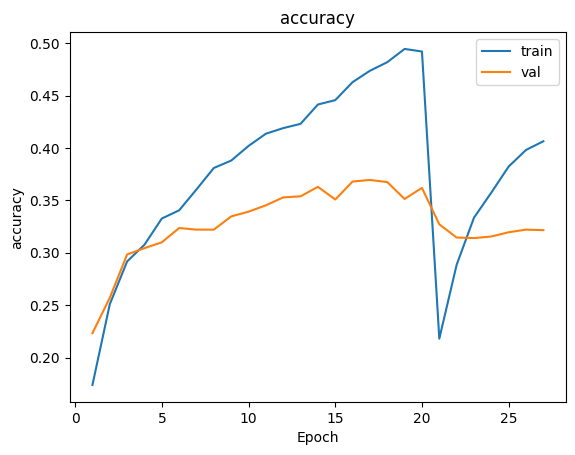

ValueError: x and y must have same first dimension, but have shapes (27,) and (0,)

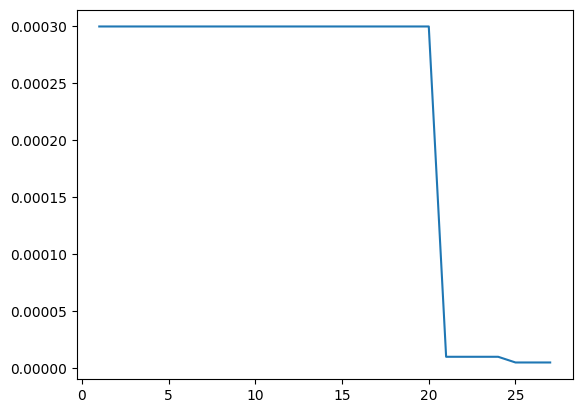

In [ ]:
# Skin Lesion Classifier — DermNet + HAM10000
# MobileNetV2 (Improved pipeline)

import os
import json
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf

from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input as mnv2_preprocess
from tensorflow.keras import layers, regularizers, Model
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense, Dropout
from tensorflow.keras.models import Model
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping, ReduceLROnPlateau

from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight

try:
    from sklearn.metrics import classification_report
    SKLEARN_AVAILABLE = True
except Exception:
    SKLEARN_AVAILABLE = False

import kagglehub

SEED = 42
tf.keras.utils.set_random_seed(SEED)

# Download datasets
print("Downloading DermNet dataset...")
path_dermnet = kagglehub.dataset_download("shubhamgoel27/dermnet")
print("DermNet dataset downloaded to:", path_dermnet)

print("Downloading HAM10000 dataset...")
path_ham = kagglehub.dataset_download("kmader/skin-cancer-mnist-ham10000")
print("HAM10000 dataset downloaded to:", path_ham)

# Build combined dataframe
DATA_ROOT = Path("./data")
DERMNET_DIR = Path(path_dermnet)
HAM_DIR = Path(path_ham)
OUTPUT_DIR = DATA_ROOT / "combined"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

image_records = []

# DermNet dataset loading
if DERMNET_DIR.exists():
    derm_scan_root = DERMNET_DIR / "train"
    if not derm_scan_root.exists():
        derm_scan_root = DERMNET_DIR
    for class_dir in derm_scan_root.glob("*"):
        if class_dir.is_dir():
            label = class_dir.name
            for img_path in class_dir.glob("**/*"):
                if img_path.suffix.lower() in [".jpg", ".jpeg", ".png"]:
                    image_records.append((str(img_path.resolve()), label))

# HAM10000 dataset loading
csv_candidates = list(HAM_DIR.glob("*.csv"))
if csv_candidates:
    meta = pd.read_csv(csv_candidates[0])
    # columns typically include: image_id, dx, ...
    for _, row in meta.iterrows():
        img_id = row.get('image_id') or row.get('image')
        dx = row.get('dx')
        if pd.isna(img_id) or pd.isna(dx):
            continue
        possible = list(HAM_DIR.glob(f"**/{img_id}.*"))
        found = None
        for p in possible:
            if p.suffix.lower() in [".jpg", ".jpeg", ".png"]:
                found = p
                break
        if found:
            image_records.append((str(found.resolve()), str(dx)))

records_df = pd.DataFrame(image_records, columns=["path", "label"])
labels = sorted(records_df['label'].unique())
label_to_index = {l: i for i, l in enumerate(labels)}
records_df['label_idx'] = records_df['label'].map(label_to_index)

print("Total images found:", len(records_df))
print("Number of classes:", len(labels))
print("Classes:", labels)

# Train/Val/Test split
trainval_df, test_df = train_test_split(
    records_df, test_size=0.15, random_state=SEED, stratify=records_df['label_idx']
)
# Then split train vs val
train_df, val_df = train_test_split(
    trainval_df, test_size=0.15, random_state=SEED, stratify=trainval_df['label_idx']
)

print(f"Train: {len(train_df)}, Val: {len(val_df)}, Test: {len(test_df)}")

# Config
IMG_SIZE = (256, 256)
BATCH_SIZE = 32
AUTOTUNE = tf.data.AUTOTUNE
NUM_CLASSES = len(labels)

# tf.data pipelines
def load_image(file_path, label_idx):
    img = tf.io.read_file(file_path)
    img = tf.image.decode_jpeg(img, channels=3)
    img = tf.image.resize(img, IMG_SIZE)
    img = tf.image.convert_image_dtype(img, tf.float32)  # [0,1]
    return img, tf.one_hot(label_idx, depth=NUM_CLASSES)

def make_dataset_from_df(df, shuffle=False):
    paths = df['path'].values
    labs  = df['label_idx'].values
    ds = tf.data.Dataset.from_tensor_slices((paths, labs))
    if shuffle:
        ds = ds.shuffle(buffer_size=len(df), seed=SEED, reshuffle_each_iteration=True)
    ds = ds.map(load_image, num_parallel_calls=AUTOTUNE)
    ds = ds.batch(BATCH_SIZE).prefetch(AUTOTUNE)
    return ds

train_ds = make_dataset_from_df(train_df, shuffle=True)
val_ds   = make_dataset_from_df(val_df, shuffle=False)
test_ds  = make_dataset_from_df(test_df, shuffle=False)

# Class weights (imbalance)
classes_unique = np.unique(train_df['label_idx'])
class_weights = compute_class_weight(
    class_weight='balanced',
    classes=classes_unique,
    y=train_df['label_idx']
)
class_weights_dict = {int(i): float(w) for i, w in zip(classes_unique, class_weights)}
print("Class weights:", class_weights_dict)

# Model: Augment + Preprocess inside the graph
data_augment = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.05),
    layers.RandomZoom(0.1),
    layers.RandomTranslation(0.05, 0.05),
    layers.RandomContrast(0.05),
], name="augment")

base = MobileNetV2(
    weights='imagenet',
    include_top=False,
    input_shape=IMG_SIZE + (3,)
)
base.trainable = False  # Stage 1: freeze base

inputs = layers.Input(shape=IMG_SIZE + (3,), name="image")
x = data_augment(inputs)
x = layers.Lambda(mnv2_preprocess)(x)
x = base(x, training=False)
x = GlobalAveragePooling2D()(x)
x = Dense(384, activation='relu', kernel_regularizer=regularizers.l2(1e-5))(x)
x = Dropout(0.4)(x)
outputs = Dense(NUM_CLASSES, activation='softmax', name='pred')(x)

model = Model(inputs, outputs, name="mobilenetv2_derm")

# Optimizer & loss
opt = tf.keras.optimizers.AdamW(learning_rate=3e-4, weight_decay=1e-5)
loss_fn = tf.keras.losses.CategoricalCrossentropy(label_smoothing=0.1)

model.compile(
    optimizer=opt,
    loss=loss_fn,
    metrics=[
        'accuracy',
        tf.keras.metrics.TopKCategoricalAccuracy(k=2, name='top2'),
        tf.keras.metrics.TopKCategoricalAccuracy(k=3, name='top3'),
    ],
)
model.summary()

# Callbacks
ckpt_path = "best_skin_mnv2.keras"  # full Keras model (arch+weights+opt)
checkpoint_cb = ModelCheckpoint(
    ckpt_path, monitor='val_accuracy', save_best_only=True, mode='max', verbose=1
)
early_cb = EarlyStopping(
    monitor='val_loss', patience=6, restore_best_weights=True, verbose=1
)
reduce_cb = ReduceLROnPlateau(
    monitor='val_loss', factor=0.5, patience=3, min_lr=1e-6, verbose=1
)

# Train — Stage 1
EPOCHS_STAGE1 = 20
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS_STAGE1,
    callbacks=[checkpoint_cb, early_cb, reduce_cb],
    class_weight=class_weights_dict,
    verbose=1
)

# -------------------------
# Fine-tune — Stage 2 (unfreeze last blocks)
# -------------------------
for layer in base.layers:
    n = layer.name
    if n.startswith('block_13') or n.startswith('block_14') or n.startswith('block_15') or n.startswith('Conv_1'):
        layer.trainable = True
    else:
        layer.trainable = False

model.compile(
    optimizer=tf.keras.optimizers.AdamW(learning_rate=1e-5, weight_decay=1e-5),
    loss=tf.keras.losses.CategoricalCrossentropy(label_smoothing=0.05),
    metrics=[
        'accuracy',
        tf.keras.metrics.TopKCategoricalAccuracy(k=2, name='top2'),
        tf.keras.metrics.TopKCategoricalAccuracy(k=3, name='top3'),
    ],
)

EPOCHS_STAGE2 = 15
history_fine = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS_STAGE1 + EPOCHS_STAGE2,
    initial_epoch=len(history.history['loss']),
    callbacks=[checkpoint_cb, early_cb, reduce_cb],
    class_weight=class_weights_dict,
    verbose=1
)

# -------------------------
# Save final model (.keras)
# -------------------------
model.save("final_skin_model.keras")
print("Final model saved to final_skin_model.keras")

# -------------------------
# Learning curves
# -------------------------
def plot_learning_curves(history, history_fine=None):
    # merge both histories if fine-tuning exists
    keys = set(history.history.keys())
    if history_fine is not None:
        keys = keys.union(history_fine.history.keys())
    keys = sorted([k for k in keys if not k.startswith('val_')])

    def merged(key):
        a = history.history.get(key, [])
        b = history_fine.history.get(key, []) if history_fine else []
        return a + b

    for metric in keys:
        train_vals = merged(metric)
        val_vals   = merged('val_' + metric)
        epochs = range(1, len(train_vals)+1)
        plt.figure()
        plt.plot(epochs, train_vals, label='train')
        plt.plot(epochs, val_vals, label='val')
        plt.title(metric)
        plt.xlabel("Epoch")
        plt.ylabel(metric)
        plt.legend()
        plt.show()

plot_learning_curves(history, history_fine)

# Evaluate on test set
print("\nLoading best checkpoint and evaluating on test set...")
best_model = tf.keras.models.load_model(ckpt_path)
test_metrics = best_model.evaluate(test_ds, verbose=1)
for name, val in zip(best_model.metrics_names, test_metrics):
    print(f"Test {name}: {val:.4f}")

# Confusion Matrix & optional Classification Report
print("\nGenerating predictions for confusion matrix...")
y_true = []
for _, y in test_ds:
    y_true.append(y.numpy())
y_true = np.concatenate(y_true, axis=0)  # [N, C]
y_true_idx = np.argmax(y_true, axis=1)

y_prob = best_model.predict(test_ds, verbose=1)
y_pred_idx = np.argmax(y_prob, axis=1)

cm = tf.math.confusion_matrix(y_true_idx, y_pred_idx, num_classes=NUM_CLASSES).numpy()

try:
    import pandas as pd
    cm_df = pd.DataFrame(cm, index=labels, columns=labels)
    print("\nConfusion Matrix (rows=true, cols=pred):")
    with pd.option_context('display.max_rows', None, 'display.max_columns', None):
        print(cm_df)
except Exception:
    print("\nConfusion Matrix:\n", cm)

if SKLEARN_AVAILABLE:
    print("\nClassification Report:")
    print(classification_report(y_true_idx, y_pred_idx, target_names=labels, digits=4))

# Single-image prediction helper
def predict_image(model, img_path, labels, img_size=(256,256), top_k=3):
    img = tf.io.read_file(img_path)
    img = tf.image.decode_jpeg(img, channels=3)
    img = tf.image.resize(img, img_size)
    img = tf.image.convert_image_dtype(img, tf.float32)  # [0,1]
    img = tf.expand_dims(img, axis=0)  # [1,H,W,3]
    img = mnv2_preprocess(img)         # [-1,1] for MobileNetV2

    preds = model.predict(img, verbose=0)[0]  # [C]
    probs = tf.nn.softmax(preds).numpy()
    top_idx = probs.argsort()[-top_k:][::-1]
    print(f"\nTop-{top_k} predictions for {img_path}:")
    for i in top_idx:
        print(f"  {labels[i]}: {probs[i]*100:.2f}%")
    return top_idx, probs[top_idx]

# Example usage:
# predict_image(best_model, "path/to/your/image.jpg", labels, img_size=IMG_SIZE, top_k=3)
